
Running 1D...

Running 2D...

Running 3D...


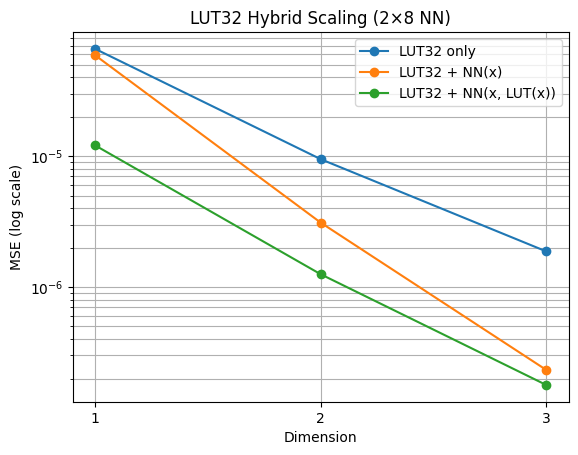


=== FINAL RESULTS ===

1D:
  LUT32 only           MSE: 6.598e-05
  Hybrid NN(x)         MSE: 5.894e-05
  Hybrid NN(x,LUT(x))  MSE: 1.207e-05

2D:
  LUT32 only           MSE: 9.483e-06
  Hybrid NN(x)         MSE: 3.104e-06
  Hybrid NN(x,LUT(x))  MSE: 1.252e-06

3D:
  LUT32 only           MSE: 1.874e-06
  Hybrid NN(x)         MSE: 2.330e-07
  Hybrid NN(x,LUT(x))  MSE: 1.787e-07


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# 1. Target functions
# -------------------------------
def f_1d(x):
    return np.sin(5*x) + 0.3*np.sin(20*x)

def f_2d(x, y):
    return np.sin(5*x)*np.cos(5*y) + np.exp(-50*((x-0.5)**2 + (y-0.5)**2))

def f_3d(x, y, z):
    return (np.sin(3*x)*np.cos(3*y)*np.sin(3*z) +
            np.exp(-20*((x-0.5)**2 + (y-0.5)**2 + (z-0.5)**2)))

# -------------------------------
# 2. LUT creation
# -------------------------------
def create_LUT(func, lut_size, dim):
    axes = [np.linspace(0, 1, lut_size) for _ in range(dim)]
    grid = np.meshgrid(*axes, indexing='ij')
    LUT = func(*grid)
    return LUT, axes

# -------------------------------
# 3. N-D LUT interpolation
# -------------------------------
def LUT_eval(LUT, axes, X):
    dim = X.shape[1]
    out = []

    for p in X:
        idx = []
        t = []

        for d in range(dim):
            a = axes[d]
            i = np.searchsorted(a, p[d]) - 1
            i = np.clip(i, 0, len(a) - 2)

            t.append((p[d] - a[i]) / (a[i + 1] - a[i]))
            idx.append(i)

        val = 0.0

        for c in range(2 ** dim):
            w = 1.0
            ind = []

            for d in range(dim):
                if (c >> d) & 1:
                    w *= t[d]
                    ind.append(idx[d] + 1)
                else:
                    w *= (1 - t[d])
                    ind.append(idx[d])

            val += w * LUT[tuple(ind)]

        out.append(val)

    return np.array(out)

# -------------------------------
# 4. NN model (2×8)
# -------------------------------
def train_nn(X, residual):
    mean = residual.mean()
    std = residual.std() + 1e-8
    y = (residual - mean) / std

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    model.fit(
        X, y,
        epochs=1200,
        batch_size=512,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=60, restore_best_weights=True)]
    )

    return model, mean, std

# -------------------------------
# 5. Run experiment
# -------------------------------
def run_case(func, dim, use_lut_input):

    X_train = np.random.rand(30000, dim)
    X_test = np.random.rand(15000, dim)

    y_train = func(*[X_train[:, i] for i in range(dim)])
    y_test = func(*[X_test[:, i] for i in range(dim)])

    LUT, axes = create_LUT(func, 32, dim)

    y_lut_train = LUT_eval(LUT, axes, X_train)
    y_lut_test = LUT_eval(LUT, axes, X_test)

    residual = y_train - y_lut_train

    if use_lut_input:
        X_train_in = np.concatenate([X_train, y_lut_train.reshape(-1, 1)], axis=1)
        X_test_in = np.concatenate([X_test, y_lut_test.reshape(-1, 1)], axis=1)
    else:
        X_train_in = X_train
        X_test_in = X_test

    nn, mean, std = train_nn(X_train_in, residual)

    nn_pred = nn.predict(X_test_in, verbose=0).reshape(-1)
    y_hybrid = y_lut_test + nn_pred * std + mean

    mse_lut = np.mean((y_lut_test - y_test) ** 2)
    mse_hybrid = np.mean((y_hybrid - y_test) ** 2)

    return mse_lut, mse_hybrid

# -------------------------------
# 6. Run all dims
# -------------------------------
dims = [1, 2, 3]

results = {
    "lut": [],
    "nn_x": [],
    "nn_x_lut": []
}

for d in dims:
    print(f"\nRunning {d}D...")

    func = globals()[f"f_{d}d"]

    mse_lut, mse_nn_x = run_case(func, d, False)
    _, mse_nn_x_lut = run_case(func, d, True)

    results["lut"].append(mse_lut)
    results["nn_x"].append(mse_nn_x)
    results["nn_x_lut"].append(mse_nn_x_lut)

# -------------------------------
# 7. Plot
# -------------------------------
plt.figure()

plt.plot(dims, results["lut"], marker='o', label='LUT32 only')
plt.plot(dims, results["nn_x"], marker='o', label='LUT32 + NN(x)')
plt.plot(dims, results["nn_x_lut"], marker='o', label='LUT32 + NN(x, LUT(x))')

plt.yscale('log')
plt.xticks([1, 2, 3])
plt.xlabel("Dimension")
plt.ylabel("MSE (log scale)")
plt.title("LUT32 Hybrid Scaling (2×8 NN)")
plt.grid(True, which='both')
plt.legend()

plt.show()

# -------------------------------
# 8. Print results
# -------------------------------
print("\n=== FINAL RESULTS ===")
for i, d in enumerate(dims):
    print(f"\n{d}D:")
    print(f"  LUT32 only           MSE: {results['lut'][i]:.3e}")
    print(f"  Hybrid NN(x)         MSE: {results['nn_x'][i]:.3e}")
    print(f"  Hybrid NN(x,LUT(x))  MSE: {results['nn_x_lut'][i]:.3e}")